<a href="https://colab.research.google.com/github/PinkOrangeSapphire/229352/blob/main/Lab09_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #9

[Recipe for Training Neural Networks](https://karpathy.github.io/2019/04/25/recipe/)

In [34]:
%%capture
!git clone https://github.com/donlapark/ds352-labs.git

In [35]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

## Training a neural network in PyTorch

### Chihuahua or Muffin?

<center><img src="https://donlapark.pages.dev/229352/lab09-preview.jpg" width="500"/></center>

### 1. Data preparation

#### Load images, resize them to 128x128, and normalize the pixels to be in 0 - 1 range

In [36]:
transform = transforms.Compose([transforms.Resize((128, 128)),
                                transforms.ToTensor()])  # transform pixels to be in 0 - 1 range

dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/train",
                                         transform=transform)

#### Split the dataset into training (80%), validation (20%)

In [37]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#### Load the datasets into DataLoader

In [38]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=10,
                          shuffle=True)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=len(val_dataset),
                        shuffle=False)

#### Do the same for the test images

In [39]:
test_dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/test",
                                    transform=transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=len(test_dataset),
                         shuffle=False)

#### Looking at the first minibatch

In [40]:
train_batches = iter(train_loader)
X, y = next(train_batches)

print(X.shape)  # (batch_size, channel, height, weight)
print(y.shape)

torch.Size([10, 3, 128, 128])
torch.Size([10])


#### Visualize the first four images in the batch

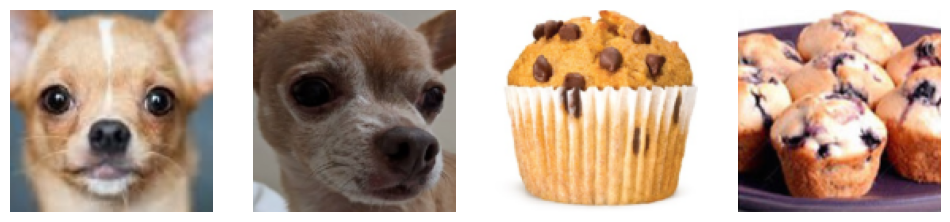

tensor([0, 0, 1, 1])


In [41]:
X = X[:4]  # Select the first 4 images
X = X.numpy().transpose(0, 2, 3, 1)  # Convert from (B, C, H, W) to (B, H, W, C)

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    axes[i].imshow(X[i])
    axes[i].axis('off')
plt.show()

print(y[:4])

### 2. Build a simple logistic regression

<center><img src="https://donlapark.pages.dev/229352/logistic.png" width="300"/></center>

The most important component of the model class is the `__init__` method and the `forward` method.  

[Linear layer in Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

[Activation functions in PyTorch](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity). The most important ones are [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), [Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html), [Softmax](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html), [Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html).

In [42]:
class SimpleLogisticRegression(nn.Module):
  def __init__(self):
        super(SimpleLogisticRegression, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 128 * 3, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )

  def forward(self, x):
        return self.model(x)

### 3. Initialize training components

#### Initialize the model and loss function

[Loss functions in PyTorch](https://pytorch.org/docs/stable/nn.html#loss-functions). Most important ones are [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [Binary cross, entropy](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), [Categorical cross entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

In [43]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()

#### Manually setting initial weights to zero for demonstration

In [44]:
with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

#### Create two lists to collect training and validation losses

In [45]:
# List to store the loss values for plotting
train_losses = []
val_losses = []

#### Specify the learning rate

In [46]:
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

### 4. Training the model with gradient descent

#### Convert the dataloader into minibatches

In [47]:
X, y = next(train_batches)

#### Make a prediction on the minibatch (Forward pass)

In [48]:
y_hat = model(X)

y = y.to(torch.float32)
y_hat = y_hat[:, 0]

#y_hat = y_hat[:, 0]
#y = y.to(torch.float32)

#### Calculate the loss function

Recall that `criterion()` is our binary cross-entropy loss (`BCELoss`).

In [49]:
# Compute the loss
train_loss = criterion(y_hat, y)
train_losses.append(train_loss)

#### Calculate the gradient (Backward pass)

In [50]:
# Backward pass: compute the gradient of the loss w.r.t. model parameters
model.parameters()

<generator object Module.parameters at 0x788edeef20a0>

#### Perform a gradient descent step

Careful! We must not include this step in the gradient calculation, hence the use of `with torch.no_grad()`.

In [51]:
# Manually update the weights using the gradient descent rule
optimizer.step() #parameter = learning rate * gradient_of_parameter

# Zero the gradients after updating
model.zero_grad()

#### Do the same for the validation set

Careful! Anything in the validation step must not be included in the gradient calculation, hence the use of `with torch.no_grad()`.

In [52]:
with torch.no_grad():
  for X, y in val_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)
    print(y_hat, y)
    val_loss = criterion(y_hat, y)
    val_losses.append(val_loss.item())

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]) tensor([0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 0., 1., 0., 0.])


In [53]:
print(train_losses)
print(val_losses)

[tensor(4.6052, grad_fn=<DivBackward1>)]
[34.958595275878906]


#### Combine everything together.

Repeat the previous steps for 20 **epochs** and plot the training and validation losses.

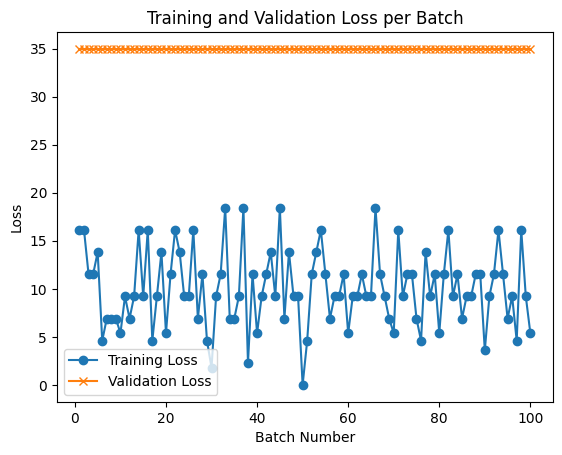

In [54]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

train_losses = []
val_losses = []

learning_rate = 1e-4

for epoch in range(10):
  for X, y in train_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)

    loss = criterion(y_hat, y)
    train_losses.append(loss.item())

    loss.backward()
    optimizer.step()

    # Zero the gradients after updating
    model.zero_grad()

    with torch.no_grad():
      for X, y in val_loader:
        y_hat = model(X)
        y_hat = y_hat[:, 0]
        y = y.to(torch.float32)
        val_loss = criterion(y_hat, y)
        val_losses.append(val_loss)

# Plot the training and validation loss
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='x', label='Validation Loss')
plt.title('Training and Validation Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Exercise

In this exercise, we will add more layers to our classification model.

<img src="https://donlapark.pages.dev/229352/lab09-architecture.png" width="450"/>

1. Create a neural network with 3 hidden layers as shown in the picture.

2. Train the model with learning rate = 1e-2, 1e-3, 1e-4, 1e-5, and answer the following questions.
    2.1 What value of learning rate do you **think** is the best? Please explain your reason.
    2.2 What happens to the training losses if your learning rate is too large?
    2.3 What happens to the training losses if your learning rate is too small?

3. After finish training your model. Make the predictions on the test set and compute the accuracy. You may use the provided code below.

4. Use `plt.imshow()` to display at least four images that are incorrectly classified by this model.

In [55]:
# Use this code to calculate test accuracy
with torch.no_grad():
  test_batches = iter(test_loader)
  X, y = next(test_batches)
  y_hat = model(X)
  y_hat = y_hat[:, 0]
  y_hat = (y_hat > 0.5).float()  # the predictions
  ##TODO: compute accuracy


In [56]:
#Create a neural network with 3 hidden layers as shown in the picture.
class ThreeHiddenNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 128 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()   # for binary classification
        )

    def forward(self, x):
        return self.network(x)


In [57]:
#Train the model with learning rate = 1e-2, 1e-3, 1e-4, 1e-5, and answer the following questions.

learning_rates = [1e-2, 1e-3, 1e-4, 1e-5]
num_epochs = 10

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = ThreeHiddenNN()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs[:, 0], y_batch.float())

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")



Training with learning rate = 0.01
Epoch [1/10], Loss: 500.6966
Epoch [2/10], Loss: 540.0000
Epoch [3/10], Loss: 540.0000
Epoch [4/10], Loss: 546.6667
Epoch [5/10], Loss: 553.3333
Epoch [6/10], Loss: 546.6667
Epoch [7/10], Loss: 546.6667
Epoch [8/10], Loss: 553.3333
Epoch [9/10], Loss: 533.3333
Epoch [10/10], Loss: 533.3333

Training with learning rate = 0.001
Epoch [1/10], Loss: 9.8448
Epoch [2/10], Loss: 9.4729
Epoch [3/10], Loss: 7.3826
Epoch [4/10], Loss: 5.3731
Epoch [5/10], Loss: 5.6191
Epoch [6/10], Loss: 5.5485
Epoch [7/10], Loss: 3.9904
Epoch [8/10], Loss: 3.2389
Epoch [9/10], Loss: 3.2863
Epoch [10/10], Loss: 2.0560

Training with learning rate = 0.0001
Epoch [1/10], Loss: 7.1007
Epoch [2/10], Loss: 6.5198
Epoch [3/10], Loss: 5.8870
Epoch [4/10], Loss: 5.1623
Epoch [5/10], Loss: 4.6354
Epoch [6/10], Loss: 4.1828
Epoch [7/10], Loss: 3.8850
Epoch [8/10], Loss: 3.2796
Epoch [9/10], Loss: 3.2820
Epoch [10/10], Loss: 2.7189

Training with learning rate = 1e-05
Epoch [1/10], Loss:

2.1 Based on the training results, the best learning rate is 1e-4. This learning rate produces a smooth and consistent decrease in training loss across epochs, indicating stable convergence toward the minimum. Unlike 1e-2, which causes instability and extremely large loss values, and 1e-5, which decreases the loss very slowly, 1e-4 achieves the lowest final loss with steady improvement. Although 1e-3 reduces the loss quickly at the beginning, it shows some fluctuations and slight instability compared to 1e-4. Therefore, 1e-4 provides the best balance between convergence speed and stability.

2.2 If the learning rate is too large, the training loss becomes unstable and may oscillate or even explode. This happens because the optimization steps are too big, causing the model parameters to overshoot the minimum instead of gradually approaching it. As a result, the loss may increase dramatically or fail to converge, preventing the model from learning effectively.

2.3 If the learning rate is too small, the training loss decreases very slowly. The model takes very small update steps during optimization, which makes convergence extremely slow. Although the training process remains stable, the model may require many more epochs to reach a good solution. In limited training time, this can lead to underfitting because the model does not have enough time to reach the optimal minimum.

In [58]:
#After finish training your model. Make the predictions on the test set and compute the accuracy. You may use the provided code below.
with torch.no_grad():
    correct = 0
    total = 0

    for X, y in test_loader:
        y_hat = model(X)
        y_hat = y_hat[:, 0]
        y_hat = (y_hat > 0.5).float()

        correct += (y_hat == y).sum().item()
        total += y.size(0)

    accuracy = correct / total
    print("Test Accuracy:", accuracy)


Test Accuracy: 0.6666666666666666


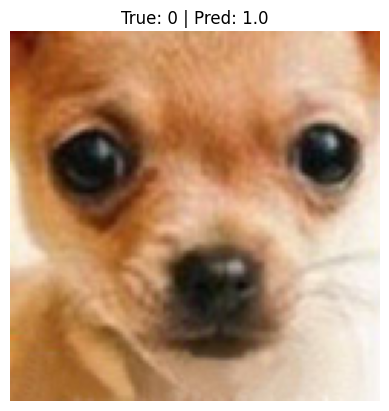

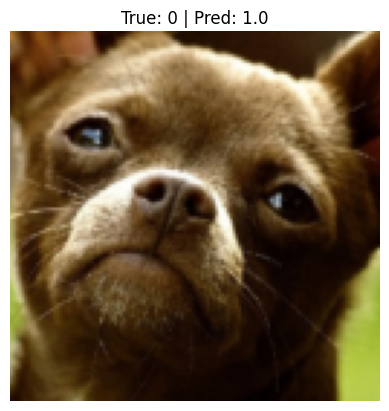

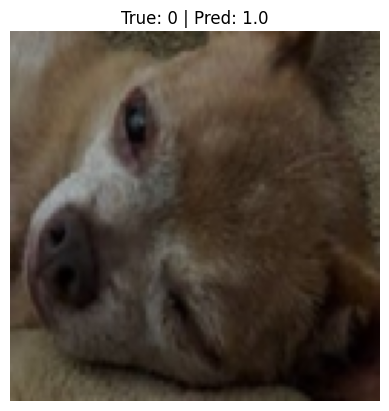

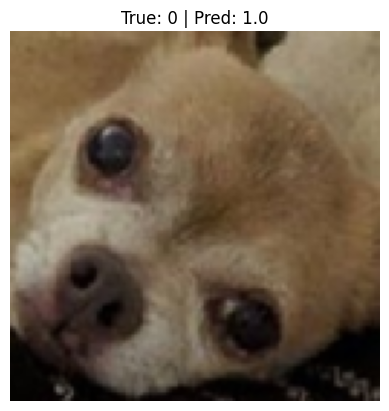

In [59]:
#Use plt.imshow() to display at least four images that are incorrectly classified by this model.
import matplotlib.pyplot as plt

misclassified = []

with torch.no_grad():
    for X, y in test_loader:
        outputs = model(X)
        preds = (outputs[:, 0] > 0.5).float()

        for i in range(len(y)):
            if preds[i] != y[i]:
                misclassified.append((X[i], y[i], preds[i]))

            if len(misclassified) == 4:
                break
        if len(misclassified) == 4:
            break

# Plot them
for i in range(4):
    img, true_label, pred_label = misclassified[i]

    img = img.permute(1, 2, 0)  # convert to HWC for plt

    plt.figure()
    plt.imshow(img)
    plt.title(f"True: {true_label.item()} | Pred: {pred_label.item()}")
    plt.axis("off")
